# Data Project

## Question 1

In [151]:
# Importing necessary packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1.1

To examine the development of inequality in Denmark since 1987, we use statistics on the Gini coefficient and the total income share of the richest 10 percent. The data on the Gini coefficient and income is obtained from Statistics Denmark and used to illustrate the development of income inequality over time.

In [152]:
# Importing relevant data
from dstapi import DstApi

import Dataproject_1ab as dp

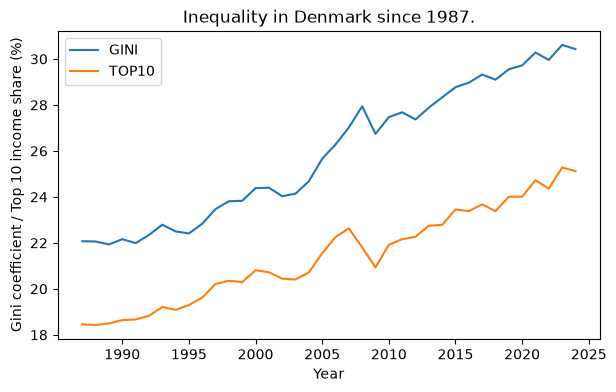

In [153]:
# Plotting figure 
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(dp.merged['TID'], dp.merged['GINI'], label='GINI')
ax.plot(dp.merged['TID'], dp.merged['TOP10'], label='TOP10')


ax.set_title('Inequality in Denmark since 1987.')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient / Top 10 income share (%)')
ax.legend();

In [154]:
# Calculation of correlation between GINI and TOP10

correlation = dp.merged['GINI'].corr(dp.merged['TOP10'])
print(f'Correlation between GINI and TOP10 is: {correlation:.6f}')

Correlation between GINI and TOP10 is: 0.981642


We find that inequality in Denmark has increased since 1987. The figure shows that both the Gini coefficient and the income share of the richest 10 percent have increased. The Gini coefficient has increased from around 22 to about 30, while the income share of the richest 10 percent has increased from about 18.5 percent to 24 percent. The two measures therefore show a similar development. This is also supported by the correlation of 0.98, which indicates a very strong positive relationship between the two measures.

## Question 1.2

Here we predict the inequality for the years 2030 and 2040, by creating both a linear and a quadratic trend to the Gini coefficient. 

First, we define t as the number of years since 1987 and y as the Gini coefficient. We then create a linear and a quadratic trend to describe how the Gini coefficient has developed over time. We use minimize to find the coefficients that make the predicted values as close as possible to the actual Gini values.

In [155]:
# Defining t (years) and y (Gini)

t = dp.merged['TID'] - 1987
y = dp.merged['GINI']

In [156]:
# Calculating linear 
def s_linear(beta):
    y_prediction = beta[0] + beta[1] * t
    sum = ((y - y_prediction) ** 2).sum()

    return sum

from scipy.optimize import minimize

result_linear = minimize(s_linear, [0, 0])

result_linear.x

array([21.04275355,  0.26354959])

In [157]:
# Calculating quadratic 
def s_quadratic(beta):
    y_prediction = beta[0] + beta[1]* t + beta[2] * t**2
    sum = ((y - y_prediction) ** 2).sum()

    return sum
    
from scipy.optimize import minimize
    
result_quadratic = minimize(s_quadratic, [0, 0, 0])
    
result_quadratic.x

array([2.13041867e+01, 2.19975902e-01, 1.17767450e-03])

In [158]:
# Calculating and comparing with np.polyfit for: 

# a) linear
print(np.polyfit(t, y, 1))

# b) quadratic
print(np.polyfit(t, y, 2))


[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


In [159]:
# Predicting the Gini coefficient in 2030 for:

t_2030 = 2030 - 1987

# a) linear

def s_linear_2030(beta):
    gini_linear_2030 =  beta[0] + beta[1] * t_2030

    return gini_linear_2030

print('Linear Gini in 2030 is:', s_linear_2030(result_linear.x))

# b) quadratic
def s_quadratic_2030(beta):
    gini_quadratic_2030 =  beta[0] + beta[1] * t_2030 + beta[2] * t_2030 **2

    return gini_quadratic_2030

print('Quadratic Gini in 2030 is:', s_quadratic_2030(result_quadratic.x))



Linear Gini in 2030 is: 32.37538611098807
Quadratic Gini in 2030 is: 32.94067063473604


In [160]:
# Predicting the Gini coefficient in 2040 for:

t_2040 = 2040 - 1987

# a) linear

def s_linear_2040(beta):
    gini_linear_2040 =  beta[0] + beta[1] * t_2040

    return gini_linear_2040

print('Linear Gini in 2040 is:', s_linear_2040(result_linear.x))

# b) quadratic
def s_quadratic_2040(beta):
    gini_quadratic_2040 =  beta[0] + beta[1] * t_2040 + beta[2] * t_2040 **2

    return gini_quadratic_2040

print('Quadratic Gini in 2040 is:', s_quadratic_2040(result_quadratic.x))


Linear Gini in 2040 is: 35.01088205439406
Quadratic Gini in 2040 is: 36.270997179924024


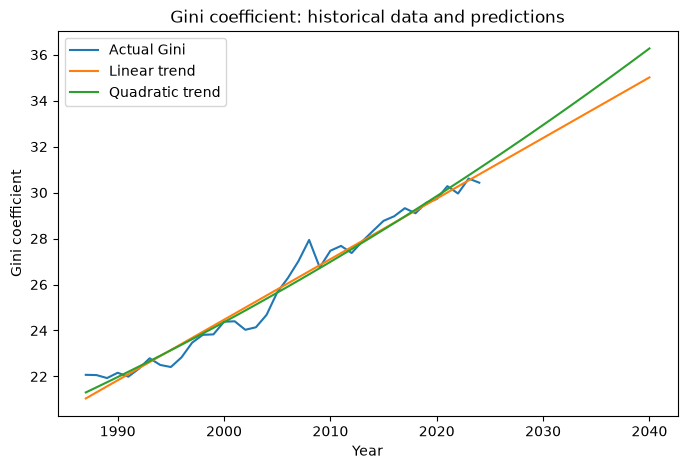

In [161]:
# Plotting the values 
years_plot = np.arange(1987, 2041)
t_plot = years_plot - 1987

beta_linear = result_linear.x
beta_quadratic = result_quadratic.x

gini_linear_plot = beta_linear[0] + beta_linear[1] * t_plot

gini_quadratic_plot = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)

# Plotting the results in a figure 
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(dp.merged['TID'], dp.merged['GINI'], label='Actual Gini')
ax.plot(years_plot, gini_linear_plot, label='Linear trend')
ax.plot(years_plot, gini_quadratic_plot, label='Quadratic trend')

ax.set_title('Gini coefficient: historical data and predictions')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.legend()

The figure shows both the linear and quadratic predictions together with the actual Gini coefficient that we calculated in the previous question. The figure shows that both the linear and quadratic models follow a similar trend. The linear model is a straight line that assumes that Gini increases by the same amount every year. The quadratic model, however, allows the increase in Gini to vary over time. The predictions for 2030 and 2040 are slightly different. The linear model predicts a slightly smaller increase in Gini than the quadratic model.

Even though both models predict that Gini will continue to increase in the future, it is important to note that these models do not take economic or political events into account, which could influence the future development of the Gini coefficient. Therefore, these predictions should be taken with a grain of salt, since they predict developments far into the future.


##  Question 1.3

In [162]:
import Dataproject_1c as dp2

In [163]:
# Correlation between gini and Top10 incomers for municipalities
correlation_municipalities = dp2.merged_municipalities['GINI'].corr(
    dp2.merged_municipalities['TOP10']
)

print(f'Correlation between the munucipalities GINI and TOP10 is: {correlation_municipalities:.6f}')

Correlation between the munucipalities GINI and TOP10 is: 0.960545


In [164]:
# Convert GINI to numeric
dp2.gini_municipalities['GINI'] = pd.to_numeric(dp2.gini_municipalities['GINI'])

# Find the most recent year
recent_year = dp2.gini_municipalities['TID'].max()

# Keep observations from the most recent year
data_for_2024 = dp2.gini_municipalities[
    dp2.gini_municipalities['TID'] == recent_year
]

# Find the 10 municipalities with the highest Gini
most_unequal = data_for_2024.nlargest(10, 'GINI')

print('The top 10 most unequal municipalites are:')
display(most_unequal)

# Find the 10 municipalites with the lowest Gini
most_equal = data_for_2024.nsmallest(10, 'GINI')

print('')
print('The top 10 most equal municipalites are:')
display(most_equal)


The top 10 most unequal municipalites are:


,KOMMUNEDK,TID,GINI
3471,Gentofte,2024,49.04
3489,Rudersdal,2024,47.31
3529,Vejen,2024,46.32
3488,Hørsholm,2024,40.07
3478,Lyngby-Taarbæk,2024,39.28
3467,Frederiksberg,2024,36.54
3466,Copenhagen,2024,34.97
3547,Aarhus,2024,33.43
3485,Fredensborg,2024,32.76
3486,Helsingør,2024,30.55



The top 10 most equal municipalites are:


,KOMMUNEDK,TID,GINI
3514,Faaborg-Midtfyn,2024,23.77
3490,Egedal,2024,23.85
3511,Bornholm,2024,24.03
3500,Faxe,2024,24.09
3494,Halsnæs,2024,24.41
3541,Favrskov,2024,24.41
3513,Assens,2024,24.46
3550,Hedensted,2024,24.58
3475,Albertslund,2024,24.66
3542,Odder,2024,24.70


The least equal:


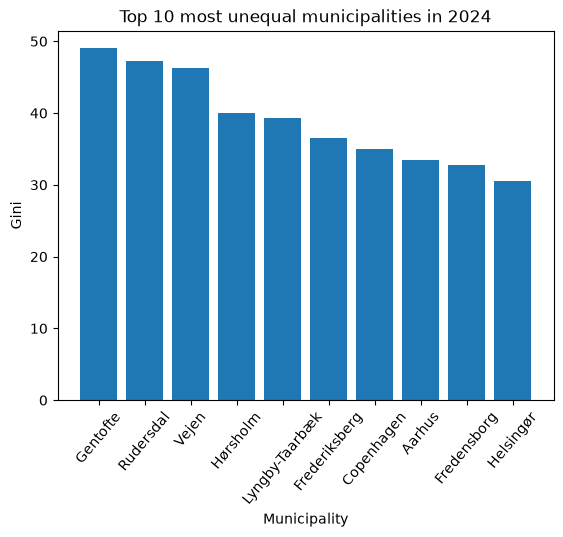


The most equal:


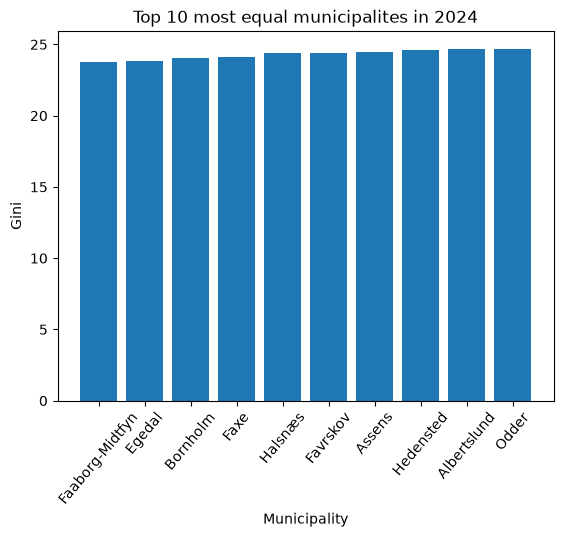

In [165]:
# Plotting the data into figures:

# a) for the 10 most unequal
plt.bar(most_unequal['KOMMUNEDK'], most_unequal['GINI'])

plt.xlabel('Municipality')
plt.ylabel('Gini')
plt.title('Top 10 most unequal municipalities in 2024')

plt.xticks(rotation = 50)

print('The least equal:')
plt.show()

# b) for the 10 most equal
plt.bar(most_equal['KOMMUNEDK'], most_equal['GINI'])

plt.xlabel('Municipality')
plt.ylabel('Gini')
plt.title('Top 10 most equal municipalites in 2024')

plt.xticks(rotation = 50)

print('')
print('The most equal:')
plt.show()

The two figures show the 10 most and the 10 least unequal municipalities in the most recent year, 2024. Gentofte has the highest Gini coefficient at almost 50, followed by Rudersdal and Vejen, which both have a Gini coefficient of around 47–48. The municipalities with the lowest Gini coefficients are much closer to each other, with values around 24–25.

The most noteworthy observation from the figures is that there is a larger difference between the municipalities at the top of the ranking than between those at the bottom. This indicates that there is greater variation in income inequality among the most unequal municipalities, while the least unequal municipalities have relatively similar levels of inequality.

In [166]:
first_year = dp2.gini_municipalities['TID'].min()
latest_year = dp2.gini_municipalities['TID'].max()

print(first_year, latest_year) 

1987 2024


In [167]:
# Find the first and the most recent year in the data
first_year = dp2.gini_municipalities['TID'].min()
latest_year = dp2.gini_municipalities['TID'].max()

# Select Gini data from the first year
gini_first = dp2.gini_municipalities[
    dp2.gini_municipalities['TID'] == first_year
]

# Select Gini data from the most recent year
gini_latest = dp2.gini_municipalities[
    dp2.gini_municipalities['TID'] == latest_year
]

# Merge the first and latest year by municipality
gini_change = pd.merge(
    gini_first,
    gini_latest,
    on='KOMMUNEDK',
    how='inner',
    suffixes=('_first', '_latest')
)

# Calculate the change in Gini between the first and latest year
gini_change['CHANGE'] = (
    gini_change['GINI_latest'] - gini_change['GINI_first']
)

# Find the municipalities with the largest and smallest change in Gini
largest_change = gini_change.nlargest(1, 'CHANGE')
smallest_change = gini_change.nsmallest(1, 'CHANGE')

display(largest_change)
display(smallest_change)

,KOMMUNEDK,TID_first,GINI_first,TID_latest,GINI_latest,CHANGE
64,Vejen,1987,21.2,2024,46.32,25.12


,KOMMUNEDK,TID_first,GINI_first,TID_latest,GINI_latest,CHANGE
62,Fanø,1987,25.67,2024,26.34,0.67


Vejen shows the largest increase in the Gini coefficient, rising from 21.20 in 1987 to 46.32 in 2024. Fanø shows the smallest change, increasing only from 25.67 to 26.34. This suggests that income inequality has increased much more strongly in Vejen than in Fanø over the period.

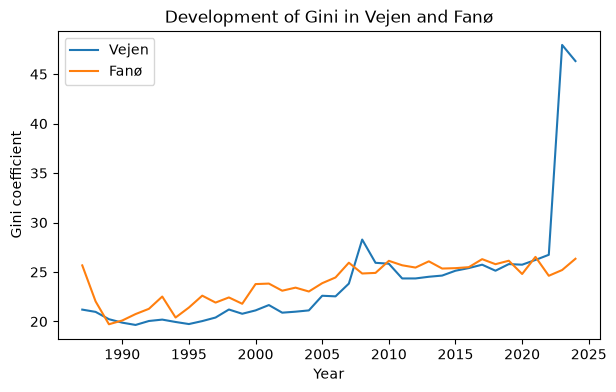

In [168]:
# Select data for Vejen and Fanø
vejen = dp2.gini_municipalities[
    dp2.gini_municipalities['KOMMUNEDK'] == 'Vejen'
]

fano = dp2.gini_municipalities[
    dp2.gini_municipalities['KOMMUNEDK'] == 'Fanø'
]

# Plot the development of Gini over time
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)

# Sorting after the years 
vejen = vejen.sort_values('TID')
fano = fano.sort_values('TID')

ax.plot(vejen['TID'], vejen['GINI'], label='Vejen')
ax.plot(fano['TID'], fano['GINI'], label='Fanø')

ax.set_title('Development of Gini in Vejen and Fanø')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.legend()
plt.show()

The figure shows the development of the Gini coefficient in Vejen and Fanø from 1987 to 2024. Fanø has a relatively stable development, with only a small increase in the Gini coefficient over time. Vejen follows a similar pattern for most of the period, but shows a very large increase in the final years. This explains why Vejen has the largest change in the Gini coefficient, while Fanø has the smallest change.

## Question 1.4

In [169]:
import Dataproject_1d as dp3

display(dp3.merged_municipalities_part2.head())

,KOMMUNEDK,TID,GINI,AVERAGE_DISPOSABLE_INCOME
0,All Denmark,2016,28.97,358674
1,Copenhagen,2016,33.24,300124
2,Frederiksberg,2016,34.85,368526
3,Ballerup,2016,25.77,369497
4,Brøndby,2016,25.71,322962


In [170]:
# Correlation between Gini and average disposable incomes for municipalities
correlation_municipalities_part2 = dp3.merged_municipalities_part2['GINI'].corr(
    dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME']
)

print(f'The correlation between the munucipalities gini and  average disposable incomes is: {correlation_municipalities_part2:.6f}')

The correlation between the munucipalities gini and  average disposable incomes is: 0.661542


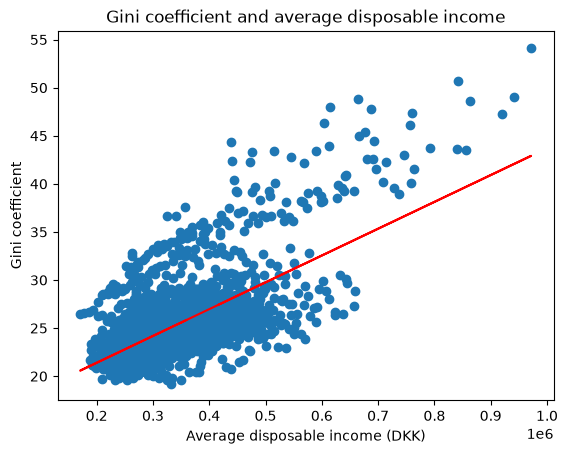

In [171]:
# Creating a scatterplot 

import matplotlib.pyplot as plt
import numpy as np

    #Convert Gini and average disposable income to numeric values
dp3.merged_municipalities_part2['GINI'] = pd.to_numeric(
    dp3.merged_municipalities_part2['GINI']
)

dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME'] = pd.to_numeric(
    dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME']
)

x = dp3.merged_municipalities_part2['AVERAGE_DISPOSABLE_INCOME'].to_numpy()
y = dp3.merged_municipalities_part2['GINI'].to_numpy()


plt.scatter(x, y)

# Add a linear trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

plt.xlabel('Average disposable income (DKK)')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient and average disposable income')


plt.show()

The figure shows a positive relationship between average disposable income and the Gini coefficient. Municipalities with higher average disposable income generally tend to have a higher Gini coefficient. This suggests that municipalities with higher average incomes also tend to have greater income inequality. However, the observations are quite spread out, so the relationship is not perfect. The figure shows a correlation, but this does not necessarily mean that higher income causes higher inequality.

# Question 2

## Question 2.1 - The model

The life-cycle model is implemented in model_2_1.py. The module simulates 50,000 individuals from age 18 to 65, including education, labor market transitions, human capital accumulation, and income. A fixed random seed is used to make the simulation reproducible.

**Imports:** We now import all the modules, we need for this notebook.

In [172]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import model_2_1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Results:** Some results from the simulation.

In [173]:
unique, counts = np.unique(
    model_2_1.education,
    return_counts=True
)

for edu, count in zip(unique, counts):
    print(edu, count / model_2_1.N)

print(model_2_1.income.shape)
print(model_2_1.human_capital.shape)

long 0.24852
medium 0.35142
short 0.40006
(50000, 48)
(50000, 48)


The simulated education shares are close to the specified probabilities of 0.40, 0.35, and 0.25 for short, medium, and long education, respectively. The income and human capital matrices both have dimensions 50,000 × 48, corresponding to 50,000 individuals observed annually from age 18 to 65.

## Question 2.2 - Simulate the income distribution

2.2.1

In [174]:
# a. education shares
unique, counts = np.unique(
    model_2_1.education,
    return_counts=True
)

simulated_shares = counts / model_2_1.N

for edu, share in zip(unique, simulated_shares):
    print(edu, share)

print("Target probabilities:", model_2_1.p_e)

long 0.24852
medium 0.35142
short 0.40006
Target probabilities: [0.4  0.35 0.25]


Result: The simulated education shares are very close to the specified probabilities p=(0.40,0.35,0.25), indicating that the education draw is implemented correctly.

In [175]:
# 2.2.1B: unemployment rate

# calculate the theoretical steady-state unemployment rate
steady_state_unemployment = (
    model_2_1.job_separation /
    (model_2_1.job_separation + model_2_1.job_finding)
)

print(steady_state_unemployment)

# create an empty list to store the unemployment rate for each age
unemployment_rate = []

# calculate the simulated unemployment rate over the life cycle
for t, age in enumerate(model_2_1.ages):

    # identify individuals who have entered the labor market
    in_labor_market = age >= model_2_1.entry_age

    # identify unemployed individuals in the labor market
    unemployed = (
        in_labor_market
        & ~model_2_1.employed[:, t]
    )

    # calculate unemployment rate only when the labor market is non-empty
    if in_labor_market.sum() > 0:
        rate = unemployed.sum() / in_labor_market.sum()
    else:
        rate = np.nan

    # store the unemployment rate for the current age
    unemployment_rate.append(rate)

0.07692307692307693


We run some prints to show that the stimulated unemployment rate settles at the theoretical steady-state-value.

In [176]:
# print simulated unemployment rates at selected ages
print("Age 30:", unemployment_rate[30 - 18])
print("Age 45:", unemployment_rate[45 - 18])
print("Age 60:", unemployment_rate[60 - 18])

Age 30: 0.07718
Age 45: 0.07774
Age 60: 0.07644


We find that the simulated unemployment rate settles close to the theoretical steady-state value of 7.69%. At ages 30, 45, and 60, the unemployment rate is approximately 7.72%, 7.77%, and 7.64%, respectively. This indicates that the simulated labor market transitions are consistent with the theoretical steady state.

2.2.2

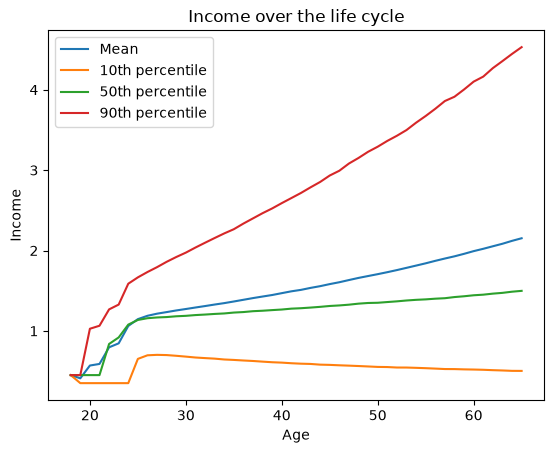

In [177]:
# 2.2.2 - mean and percentiles of income over the life cycle

# calculate mean income at each age
mean_income = np.mean(model_2_1.income, axis=0)

# calculate selected income percentiles at each age
p10_income = np.percentile(model_2_1.income, 10, axis=0)
p50_income = np.percentile(model_2_1.income, 50, axis=0)
p90_income = np.percentile(model_2_1.income, 90, axis=0)

# plot mean and selected percentiles of income over the life cycle

plt.plot(model_2_1.ages, mean_income, label='Mean')
plt.plot(model_2_1.ages, p10_income, label='10th percentile')
plt.plot(model_2_1.ages, p50_income, label='50th percentile')
plt.plot(model_2_1.ages, p90_income, label='90th percentile')

# add labels and title
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income over the life cycle')

# add legend
plt.legend()

# show the figure
plt.show()

Analysis: 
The figure shows that income differences increase over the life cycle. At younger ages, incomes are relatively similar because many individuals are still in education and receive the student grant of 0.45. As individuals enter the labor market, the income distribution starts to spread out. In particular, the 90th percentile increases much faster than the median, as differences in human capital accumulate over time. At the same time, the 10th percentile decreases at older ages, partly reflecting unemployment and the depreciation of human capital. The mean therefore rises above the median, showing that high-income individuals increasingly pull up average income.

2.2.3

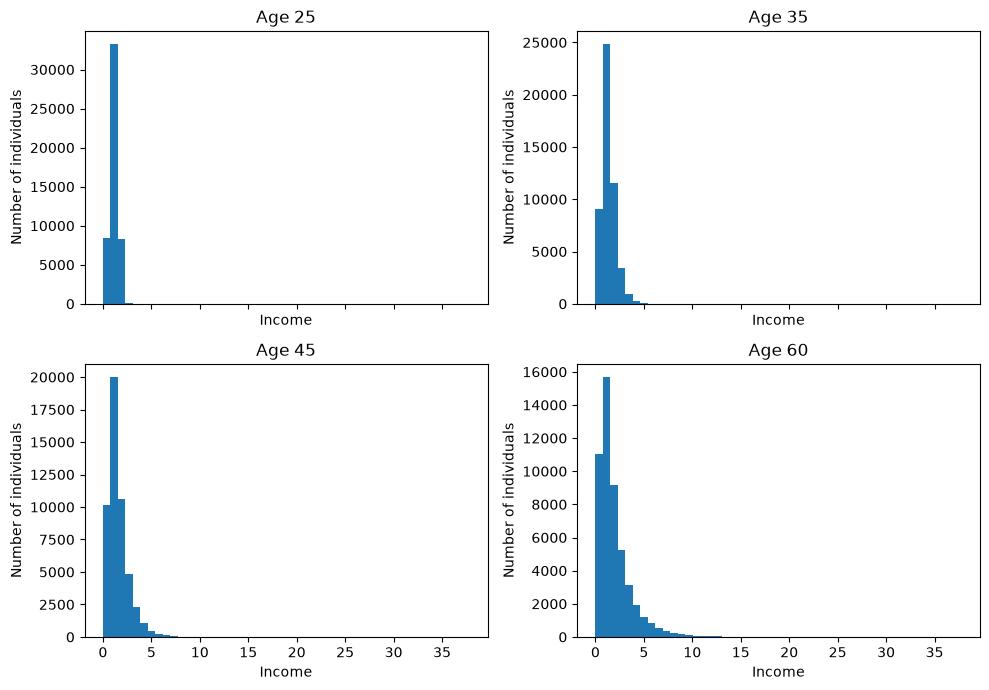

In [178]:
# 2.2.3: income distributions at selected ages

# select ages for the histograms
selected_ages = [25, 35, 45, 60]

# find the corresponding columns in the income matrix
age_indices = [age - 18 for age in selected_ages]

# create one figure with four histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

# use the same bins for all four histograms
bins = np.linspace(
    0,
    model_2_1.income[:, age_indices].max(),
    50
)

# plot income distribution at each selected age
for ax, age, index in zip(axes.flat, selected_ages, age_indices):

    ax.hist(model_2_1.income[:, index], bins=bins)

    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
    ax.set_ylabel('Number of individuals')

# adjust spacing between the plots
plt.tight_layout()

# show the figure
plt.show()

Analysis: The income distribution becomes more dispersed over the life cycle. At age 25, incomes are still relatively concentrated, as many individuals have only recently entered the labor market. As individuals get older, the distribution gradually spreads out. In particular, the right tail becomes longer, meaning that some individuals develop much higher incomes than the majority. This also explains why the mean income becomes higher than the median, as the relatively few high incomes pull up the average. This reflects differences in human capital that accumulate over time. The income distribution therefore becomes more spread out with age, as a small group of individuals earns much higher incomes than the majority.

# Question 2.3 - Compute the Gini Coefficient



**Imports:** We now import all the modules, we need for this notebook.

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import model_2_1
import model_2_4

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload




We write our own function for the Gini coefficient. The function sorts the incomes in
ascending order and uses the formula

$$ G = \frac{\sum_{i=1}^{n}(2i - n - 1)\,y_{(i)}}{n \sum_{i=1}^{n} y_{(i)}} $$

where $y_{(i)}$ is the $i$'th smallest income. We also write a function that returns
the Lorenz curve.

In [180]:
# 2.3: functions for the Gini coefficient and the Lorenz curve

def gini(y):
    """ compute the Gini coefficient of a vector of incomes

    Args:
        y (ndarray): vector of incomes (non-negative)

    Returns:
        (float): the Gini coefficient
    """

    # flatten and sort the incomes in ascending order
    y = np.sort(np.asarray(y, dtype=float).ravel())

    # number of observations
    n = y.size

    # ranks from 1 to n
    i = np.arange(1, n + 1)

    # covariance-based formula for the Gini coefficient
    return np.sum((2 * i - n - 1) * y) / (n * np.sum(y))


def lorenz(y):
    """ compute the Lorenz curve of a vector of incomes

    Args:
        y (ndarray): vector of incomes (non-negative)

    Returns:
        F (ndarray): cumulative population share
        L (ndarray): cumulative income share
    """

    # flatten and sort the incomes in ascending order
    y = np.sort(np.asarray(y, dtype=float).ravel())

    # cumulative income share, starting from the origin
    L = np.concatenate(([0.0], np.cumsum(y) / np.sum(y)))

    # cumulative population share, starting from the origin
    F = np.linspace(0, 1, y.size + 1)

    return F, L

We test the function on three cases where the answer is known analytically: a uniform
distribution on $[0,1]$, where the Gini coefficient is exactly $1/3$; a lognormal
distribution whose logarithm has standard deviation $s$, where it is
$2\Phi(s/\sqrt{2}) - 1$; and perfect equality, where it is zero.

In [181]:
# 2.3: test the Gini function on cases where the answer is known

rng_test = np.random.default_rng(1917)

# a. uniform distribution on [0,1]
y_uniform = rng_test.uniform(0, 1, size=1_000_000)

print("uniform   - simulated:", round(gini(y_uniform), 4),
      "theoretical:", round(1/3, 4))

# b. lognormal distribution
s = 0.5
y_lognormal = rng_test.lognormal(0, s, size=1_000_000)

print("lognormal - simulated:", round(gini(y_lognormal), 4),
      "theoretical:", round(2 * norm.cdf(s / np.sqrt(2)) - 1, 4))

# c. perfect equality
print("equality  - simulated:", gini(np.ones(1000)),
      "theoretical:", 0.0)

uniform   - simulated: 0.3334 theoretical: 0.3333
lognormal - simulated: 0.2762 theoretical: 0.2763
equality  - simulated: 0.0 theoretical: 0.0


The function returns the correct answer in all three cases, so we can use it on the
simulated income distribution.

2.3.1

Gini coefficient, all ages pooled: 0.3777


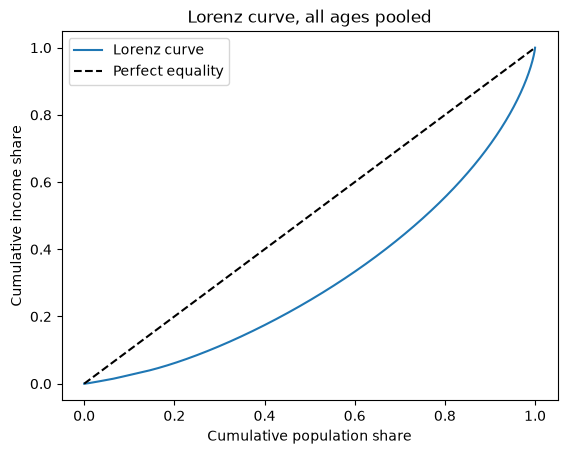

In [182]:
# 2.3.1: Gini coefficient and Lorenz curve for the full simulated sample

# pool all individuals and all ages
income_pooled = model_2_1.income.ravel()

# compute the Gini coefficient for the pooled sample
gini_pooled = gini(income_pooled)

print("Gini coefficient, all ages pooled:", round(gini_pooled, 4))

# compute the Lorenz curve
F, L = lorenz(income_pooled)

# plot the Lorenz curve together with the line of perfect equality
plt.plot(F, L, label='Lorenz curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect equality')

# add labels and title
plt.xlabel('Cumulative population share')
plt.ylabel('Cumulative income share')
plt.title('Lorenz curve, all ages pooled')

# add legend
plt.legend()

# show the figure
plt.show()

2.3.2

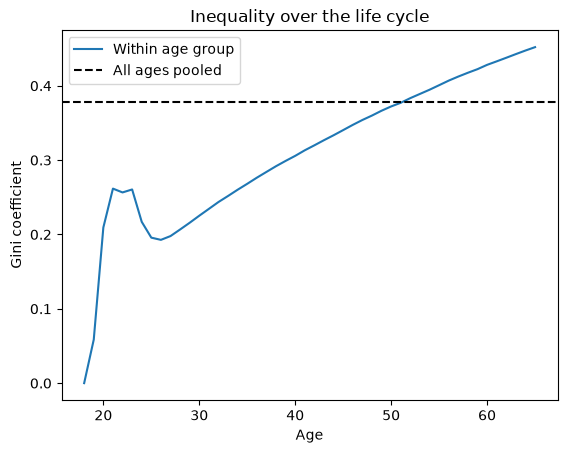

Age 18: 0.0
Age 25: 0.1957
Age 35: 0.2681
Age 45: 0.3404
Age 60: 0.4281
Age 65: 0.452
Crossing age: 52


In [183]:
# 2.3.2: Gini coefficient within each age group

# create an empty list to store the Gini coefficient for each age
gini_by_age = []

# compute the Gini coefficient separately for each age
for t, age in enumerate(model_2_1.ages):
    gini_by_age.append(gini(model_2_1.income[:, t]))

# convert to an array for convenience
gini_by_age = np.array(gini_by_age)

# plot the within-age Gini coefficient over the life cycle
plt.plot(model_2_1.ages, gini_by_age, label='Within age group')

# add the pooled Gini coefficient as a horizontal reference line
plt.axhline(gini_pooled, linestyle='--', color='black', label='All ages pooled')

# add labels and title
plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Inequality over the life cycle')

# add legend
plt.legend()

# show the figure
plt.show()

# print the Gini coefficient at selected ages
for age in [18, 25, 35, 45, 60, 65]:
    print(f"Age {age}:", round(gini_by_age[age - 18], 4))

# find the age where the within-age measure crosses the pooled measure
crossing_age = model_2_1.ages[np.argmax(gini_by_age > gini_pooled)]

print("Crossing age:", crossing_age)

**Analysis:**
The Gini coefficient for the pooled sample is 0.378, and the Lorenz curve lies clearly
below the 45-degree line.

Within a given age group, inequality follows a pronounced life-cycle profile. It is
zero at age 18, where everybody is still in education and receives the same student
grant, and then rises almost monotonically from 0.196 at age 25 to 0.452 at age 65, as
the multiplicative shocks accumulate and unemployment spells depreciate human capital.

The comparison with the pooled measure is therefore not one-directional. Up to age 51
the within-age Gini coefficient is *below* the pooled one, because pooling adds a
between-age component: a 60-year-old employed worker and a 20-year-old student differ
in income for purely life-cycle reasons, and this variation is counted as inequality
when all ages are pooled. From age 52 onwards the within-age coefficient *exceeds* the
pooled one, because by then the dispersion accumulated within the cohort is larger than
the dispersion generated by pooling ages together.

The within-age measure is the more meaningful notion of inequality here, since it
compares individuals who are otherwise similar. We return to this distinction in
question 2.4.

## Question 2.4- What drives Inequality?



In [184]:
# 2.4: check that the flexible module reproduces the baseline exactly

baseline = model_2_4.simulate()

print("identical income:", np.array_equal(baseline['income'], model_2_1.income))
print("identical employment:", np.array_equal(baseline['employed'], model_2_1.employed))

identical income: True
identical employment: True


In [185]:
# 2.4: switch off the components of the model one at a time

specifications = {
    'Baseline': {},
    'No educational differences': {'educational_differences': False},
    'No shocks to human capital': {'shocks': False},
    'No depreciation when unemployed': {'depreciation': False},
    'No unemployment': {'unemployment': False},
}

# select a single age group for the within-age comparison
age_group = 45
t_group = age_group - 18

# create an empty dictionary to store the results
results = {}

# run the alternative simulations
for name, switches in specifications.items():

    sim = model_2_4.simulate(**switches)

    results[name] = {
        'pooled': gini(sim['income']),
        'within': gini(sim['income'][:, t_group]),
        'mean': sim['income'].mean(),
    }

# print the results as a table
print(f"{'Simulation':34s}{'Pooled':>9s}{'Age 45':>9s}{'Mean y':>9s}")

for name, r in results.items():
    print(f"{name:34s}{r['pooled']:9.4f}{r['within']:9.4f}{r['mean']:9.3f}")

Simulation                           Pooled   Age 45   Mean y
Baseline                             0.3777   0.3404    1.474
No educational differences           0.3331   0.2921    1.465
No shocks to human capital           0.2788   0.2142    1.473
No depreciation when unemployed      0.3829   0.3292    1.674
No unemployment                      0.3819   0.3261    1.823


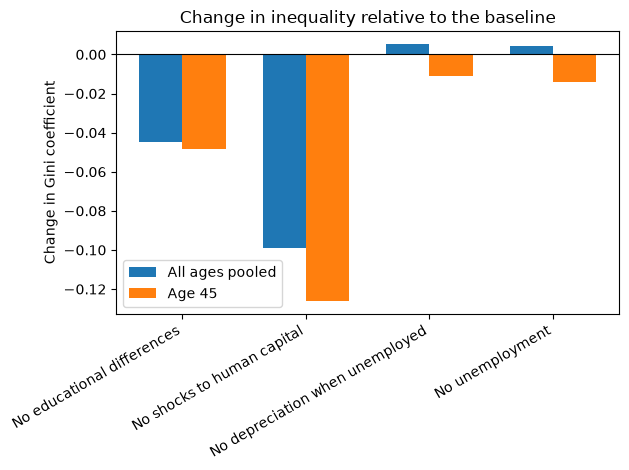

In [186]:
# 2.4: plot the change in the Gini coefficient relative to the baseline

# names of the alternative simulations
names = [name for name in specifications if name != 'Baseline']

# changes relative to the baseline
d_pooled = [results[n]['pooled'] - results['Baseline']['pooled'] for n in names]
d_within = [results[n]['within'] - results['Baseline']['within'] for n in names]

# position of the bars
x = np.arange(len(names))
width = 0.35

# plot the two sets of bars next to each other
plt.bar(x - width/2, d_pooled, width, label='All ages pooled')
plt.bar(x + width/2, d_within, width, label=f'Age {age_group}')

# add a horizontal line at zero
plt.axhline(0, color='black', linewidth=0.8)

# add labels and title
plt.xticks(x, names, rotation=30, ha='right')
plt.ylabel('Change in Gini coefficient')
plt.title('Change in inequality relative to the baseline')

# add legend
plt.legend()

# adjust spacing
plt.tight_layout()

# show the figure
plt.show()

**Analysis:**
The shock to human capital dominates. Switching it off lowers the pooled Gini from
0.378 to 0.279 and the age-45 Gini from 0.340 to 0.214: $\psi$ is multiplicative and
never reversed, so the variance of log human capital grows with years worked.
Educational differences come second (−0.045 pooled, −0.048 within age); depreciation
and unemployment matter little.

The last two simulations show the case in the hint. Removing depreciation or
unemployment lowers the age-45 Gini (to 0.329 and 0.326) but raises the pooled one (to
0.383 and 0.382). Within an age group the sign is intuitive: unemployment creates
dispersion between otherwise identical workers. The pooled measure moves the other way
because it also contains a between-age component: without unemployment, average income
rises from 1.47 to 1.82 while students stay at the grant of 0.45, so the age gap widens
by more than the within-age dispersion falls. The pooled Gini therefore mixes
inequality between individuals with mechanical age differences.

One caveat: switching off educational differences requires choosing an education for
everybody. We assign the medium one. The pooled Gini is sensitive to this (0.298, 0.333
and 0.382 with short, medium and long), but the age-45 value stays between 0.284 and
0.300, so the conclusion holds.

## Question 2.5 Extension: More Risk



In [187]:
# 2.5: simulate the model for different degrees of health risk

# values of the annual probability of a health shock
p_health_values = [0.000, 0.005, 0.010, 0.020, 0.030]

# create empty lists to store the results
ever_disabled = []
mean_income_health = []
gini_pooled_health = []
gini_age_health = []

# index of age 60
t60 = 60 - 18

# run one simulation for each value of p_health
for p in p_health_values:

    sim = model_2_4.simulate(p_health=p)

    # share of individuals who are disabled at the end of the life cycle
    ever_disabled.append(sim['disabled'][:, -1].mean())

    mean_income_health.append(sim['income'].mean())
    gini_pooled_health.append(gini(sim['income']))
    gini_age_health.append(gini(sim['income'][:, t60]))

# print the results as a table
print(f"{'p_health':>10s}{'Disabled':>10s}{'Mean y':>10s}{'Pooled':>10s}{'Age 60':>10s}")

for i, p in enumerate(p_health_values):
    print(f"{p:10.3f}{ever_disabled[i]:10.3f}{mean_income_health[i]:10.3f}"
          f"{gini_pooled_health[i]:10.4f}{gini_age_health[i]:10.4f}")

  p_health  Disabled    Mean y    Pooled    Age 60
     0.000     0.000     1.474    0.3777    0.4281
     0.005     0.202     1.383    0.3802    0.4410
     0.010     0.365     1.304    0.3804    0.4466
     0.020     0.598     1.176    0.3768    0.4436
     0.030     0.746     1.075    0.3695    0.4267


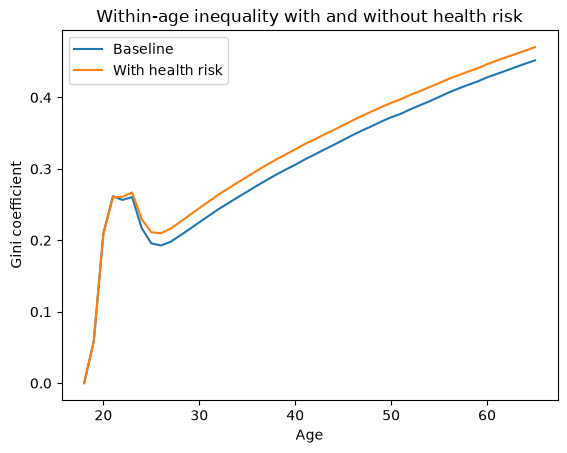

In [188]:
# 2.5: Gini coefficient over the life cycle with and without health risk

# baseline and extended simulation
sim_base = model_2_4.simulate()
sim_health = model_2_4.simulate(p_health=0.010)

# compute the within-age Gini coefficient in both simulations
gini_age_base = np.array([gini(sim_base['income'][:, t])
                          for t in range(len(model_2_4.ages))])
gini_age_ext = np.array([gini(sim_health['income'][:, t])
                         for t in range(len(model_2_4.ages))])

# plot the two life-cycle profiles
plt.plot(model_2_4.ages, gini_age_base, label='Baseline')
plt.plot(model_2_4.ages, gini_age_ext, label='With health risk')

# add labels and title
plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Within-age inequality with and without health risk')

# add legend
plt.legend()

# show the figure
plt.show()

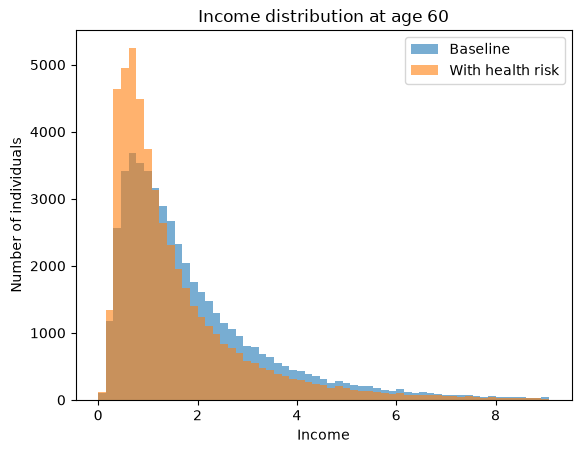

Share disabled at age 60: 0.331
Mean income, disabled: 0.877
Mean income, others: 1.999


In [189]:
# 2.5: compare the income distribution at age 60 with and without health risk

# use the same bins for both histograms
bins = np.linspace(0, np.percentile(sim_base['income'][:, t60], 99), 60)

# plot the two distributions on top of each other
plt.hist(sim_base['income'][:, t60], bins=bins, alpha=0.6, label='Baseline')
plt.hist(sim_health['income'][:, t60], bins=bins, alpha=0.6, label='With health risk')

# add labels and title
plt.xlabel('Income')
plt.ylabel('Number of individuals')
plt.title('Income distribution at age 60')

# add legend
plt.legend()

# show the figure
plt.show()

# compare the disabled with the rest of the population at age 60
is_disabled = sim_health['disabled'][:, t60]
income_60 = sim_health['income'][:, t60]

print("Share disabled at age 60:", round(is_disabled.mean(), 3))
print("Mean income, disabled:", round(income_60[is_disabled].mean(), 3))
print("Mean income, others:", round(income_60[~is_disabled].mean(), 3))

In [190]:
# 2.5: is it the amount of non-employment or its persistence that matters?

# non-employment rate at age 60 in the simulation with health risk
in_labor_market = model_2_4.ages[t60] >= sim_health['entry_age']

target = (
    (in_labor_market & ~sim_health['employed'][:, t60]).sum()
    / in_labor_market.sum()
)

# a purely temporary risk with the same steady-state non-employment rate
# requires a job-separation probability of sigma = u*lambda/(1-u)
sigma_alt = target * model_2_4.job_finding / (1 - target)

sim_temporary = model_2_4.simulate(job_separation_alt=sigma_alt)

print("Non-employment rate at age 60:", round(target, 4))
print("Implied job-separation probability:", round(sigma_alt, 4))
print()

print(f"{'':22s}{'Pooled':>9s}{'Age 60':>9s}{'Mean y':>9s}")

print(f"{'Permanent risk':22s}{gini(sim_health['income']):9.4f}"
      f"{gini(sim_health['income'][:, t60]):9.4f}{sim_health['income'].mean():9.3f}")

print(f"{'Temporary risk':22s}{gini(sim_temporary['income']):9.4f}"
      f"{gini(sim_temporary['income'][:, t60]):9.4f}{sim_temporary['income'].mean():9.3f}")

Non-employment rate at age 60: 0.383
Implied job-separation probability: 0.3724

                         Pooled   Age 60   Mean y
Permanent risk           0.3804   0.4466    1.304
Temporary risk           0.3503   0.4339    0.799


**Analysis:**
Health risk raises within-age inequality throughout the life cycle. With
$p^{h} = 0.01$, 36.5 per cent of the cohort is hit by age 65 and the age-60 Gini rises
from 0.428 to 0.447. The effect is cumulative in age: at 25 it rises only from 0.196 to
0.211, at 45 from 0.340 to 0.361. The histogram shows why: the distribution becomes
bimodal, with the disabled frozen at 60 per cent of their last wage (mean 0.88 at age
60 against 2.00 for the rest) while everybody else keeps accumulating human capital.

The pooled Gini is non-monotonic: it rises slightly for small $p^{h}$ but falls below
the baseline for $p^{h} \geq 0.02$. This is the mechanism of 2.4 in reverse. Health
shocks cut average income (1.47 to 1.08 at $p^{h}=0.03$), pushing older workers down
towards the grant of 0.45 and compressing the between-age component even as within-age
inequality keeps rising.

Finally, persistence matters in itself, not just the amount of non-employment. Setting
$\sigma$ to match the age-60 non-employment rate gives a pooled Gini of 0.350 against
0.380 under permanent risk, though the within-age gap is small (0.434 against 0.447):
the effect works mainly through the lower tail. The comparison is limited, however,
since the temporary version destroys far more human capital (mean income 0.80 against
1.30), as $\sigma = 0.37$ leaves almost everybody in long depreciating spells.